# 02 - Bias Detection and Fairness

In [5]:
import pandas as pd

df = pd.read_csv("cleaned_dataset.csv")
df.head()

,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,financials.income_unified
0,app_001,"[{'category': 'Fitness', 'amount': 576}]",NaN,Stephanie Nguyen,stephanie.nguyen47@mail.com,427-90-1892,10.121.120.213,female,1986-05-27,90230.0,37,0.42,0,False,high_dti_ratio,NaN,NaN,NaN,102000.0
1,app_002,"[{'category': 'Education', 'amount': 533}]",NaN,Kevin Roberts,kevin.roberts9@protonmail.com,992-61-4010,172.19.95.144,male,1999-08-01,10020.0,5,0.36,18200,False,algorithm_risk_score,NaN,NaN,NaN,41000.0
2,app_003,"[{'category': 'Healthcare', 'amount': 450}]",NaN,Lisa Gonzalez,lisa.gonzalez51@yahoo.com,833-33-5929,172.21.35.195,female,1982-08-24,90213.0,74,0.43,7090,True,NaN,NaN,3.4,76000.0,65000.0
3,app_004,"[{'category': 'Transportation', 'amount': 329}...",NaN,Karen Nelson,karen.nelson35@outlook.com,486-50-5539,172.31.79.76,female,02/28/1995,90217.0,9,0.41,10327,False,high_dti_ratio,NaN,NaN,NaN,69000.0
4,app_005,"[{'category': 'Insurance', 'amount': 585}]",NaN,Christine Mitchell,christine.mitchell3@outlook.com,400-91-8156,172.25.44.173,female,1960/06/19,90296.0,76,0.06,15011,False,algorithm_risk_score,NaN,NaN,NaN,39000.0


### Overview of Decision Outcomes

In [10]:
# We check the distribution of approval outcomes
df["decision.loan_approved"].value_counts(dropna=False)

decision.loan_approved
True     292
False    208
Name: count, dtype: int64

In [9]:
# We do the computation of the overall approval rate
overall_approval_rate = df["decision.loan_approved"].mean()
print(f"Overall approval rate: {overall_approval_rate:.3f}")

Overall approval rate: 0.584


### Gender-Based Approval Analysis

In [16]:
# We remove missing gender values for fairness calculation
df_gender = df.dropna(subset=["applicant_info.gender"])

gender_summary = (
    df_gender
        .groupby("applicant_info.gender")["decision.loan_approved"]
        .agg(
            approved="sum",
            total="count"
        )
)

# Then compute approval rate
gender_summary["approval_rate"] = (
    gender_summary["approved"] / gender_summary["total"]
).round(3)

gender_summary.index.name = "Gender"

gender_summary

,approved,total,approval_rate
Gender,,,
female,127,251,0.506
male,163,247,0.660


In [17]:
# Computation of the Disparate Impact Ratio (female as unprivileged group)
di_ratio = (
    gender_summary.loc["female", "approval_rate"] /
    gender_summary.loc["male", "approval_rate"]
)

print(f"Disparate Impact (DI) Ratio: {di_ratio:.3f}")

Disparate Impact (DI) Ratio: 0.767


The Disparate Impact (DI) ratio is calculated as the ratio of the female approval rate to the male approval rate.

Under the four-fifths rule, a DI value below 0.8 indicates potential disparate impact.

The computed DI suggests that female applicants are approved at a substantially lower rate relative to male applicants, indicating potential gender-based disparity in historical lending decisions.

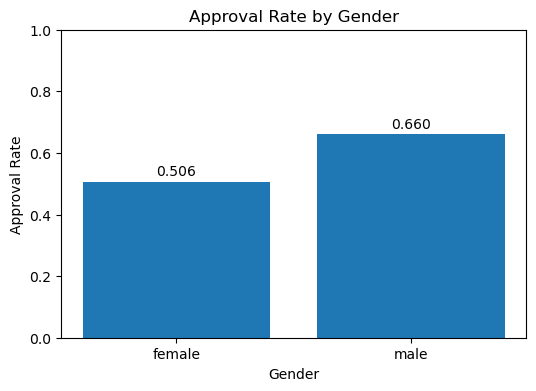

In [20]:
# We create a visualization of approval rates by gender
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

bars = plt.bar(
    gender_summary.index,
    gender_summary["approval_rate"]
)

plt.title("Approval Rate by Gender")
plt.ylabel("Approval Rate")
plt.xlabel("Gender")
plt.ylim(0, 1)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f"{height:.3f}",
        ha="center"
    )

plt.show()

The visualization confirms a noticeable disparity in approval rates between genders. Male applicants are approved at a higher rate than female applicants. This gap is consistent with the computed Disparate Impact ratio below the four-fifths threshold.